# 08 - Correlation Analysis & Hypothesis Testing
**Project:** Energy-Economy Nexus: Analyzing the Co-Movement of U.S. Electricity Price Shocks  
**and Global Macroeconomic Indicators During the 2022 - 2024 Volatility Period**

**Tim:** 
Mylovia Mahesa Ayu
Abdullah Al-Firdaus Nuzula
Fio Ulaa' Octriyanti
Muhammad Raffi Fahrezi  
**Kelas:** INT24 - S1 Sains Data FMIPA UNESA 2025/2026

---

## Hipotesis yang Diuji
| ID | Hipotesis |
|----|-----------|
| H1 | Lonjakan harga listrik industri AS 2022 berjalan seiring penurunan Industrial Production negara G7 di periode yang sama |
| H2 | Harga listrik retail AS berkorelasi positif dengan CPI global setelah dikontrol Brent Crude sebagai variabel eksogen |
| H3 | Bauran energi AS mengalami pergeseran struktural 2022–2024 yang berkorelasi negatif dengan volatilitas CPI |
| H4 | Juni–Agustus 2022 adalah periode anomali simultan di semua indikator (Z-score > 2.0) |

## Cell 1 - Install Dependencies

In [24]:
! pip install pandas numpy scipy scikit-learn matplotlib seaborn sqlalchemy psycopg2-binary python-dotenv statsmodels

## Cell 2 - Import Library & Koneksi Supabase

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import warnings
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

warnings.filterwarnings('ignore')

# Style Plot
plt.rcParams['figure.figsize']  = (14, 6)
plt.rcParams['font.size']       = 11
plt.rcParams['axes.grid']       = True
plt.rcParams['grid.alpha']      = 0.3
sns.set_palette('husl')

# Koneksi Supabase
load_dotenv("../.env")
DB_URL = os.getenv("SUPABASE_DB_URL", "")

engine = create_engine(DB_URL, pool_pre_ping=True)
print("Koneksi Supabase berhasil")

Koneksi Supabase berhasil


## Cell 3 - Load Data dari Supabase

In [26]:
fact_ee  = pd.read_sql("SELECT * FROM fact_energy_economy ORDER BY period, sector_id", engine)
fact_gen = pd.read_sql("SELECT * FROM fact_generation ORDER BY period, fuel_type_id", engine)
dim_time = pd.read_sql("SELECT * FROM dim_time ORDER BY period", engine)
dim_fuel = pd.read_sql("SELECT * FROM dim_fuel_type", engine)

fact_ee['period_dt']  = pd.to_datetime(fact_ee['period'] + '-01')
fact_gen['period_dt'] = pd.to_datetime(fact_gen['period'] + '-01')

print("Data berhasil dimuat dari Supabase")
print(f"fact_energy_economy : {fact_ee.shape}")
print(f"fact_generation     : {fact_gen.shape}")
print(f"dim_time            : {dim_time.shape}")
print(f"\nKolom fact_energy_economy:")
print(fact_ee.columns.tolist())
print(f"\nPeriod range: {fact_ee['period'].min()} → {fact_ee['period'].max()}")

Data berhasil dimuat dari Supabase
fact_energy_economy : (144, 14)
fact_generation     : (288, 9)
dim_time            : (36, 6)

Kolom fact_energy_economy:
['period', 'time_id', 'sector_id', 'country_code', 'year', 'price_cents_kwh', 'retail_sales_mwh', 'revenue_million_usd', 'cpi_pct_yoy', 'gdp_current_usd_mn', 'industrial_prod_usd', 'unemployment_rate', 'exchange_rate_lcu_usd', 'period_dt']

Period range: 2022-01 → 2024-12


## Cell 4 - Eksplorasi Data Awal (EDA)

In [27]:
print("Summary Statistics of fact_energy_economy")

cols_numeric = [
    'price_cents_kwh', 'retail_sales_mwh', 'revenue_million_usd',
    'cpi_pct_yoy', 'gdp_current_usd_mn', 'industrial_prod_usd',
    'unemployment_rate', 'exchange_rate_lcu_usd'
]
cols_exist = [c for c in cols_numeric if c in fact_ee.columns]

display(fact_ee[cols_exist].describe().round(3))

print(f"\nSektor tersedia  : {fact_ee['sector_id'].unique().tolist()}")
print(f"Negara tersedia    : {fact_ee['country_code'].unique().tolist()}")
print(f"\nMissing values   :")
missing = fact_ee[cols_exist].isnull().sum()
for col, cnt in missing[missing > 0].items():
    print(f"   {col:<30} {cnt} rows ({cnt/len(fact_ee)*100:.1f}%)")
if missing.sum() == 0:
    print("Tidak ada missing value")

Summary Statistics of fact_energy_economy


,price_cents_kwh,retail_sales_mwh,revenue_million_usd,cpi_pct_yoy,gdp_current_usd_mn,industrial_prod_usd,unemployment_rate,exchange_rate_lcu_usd
count,144.000,144.000,144.000,144.000,1.440000e+02,1.440000e+02,144.000,144.0
mean,12.292,163424.742,20690.957,5.033,2.772140e+07,2.727222e+11,3.767,1.0
std,2.820,98329.682,13321.835,2.291,1.330312e+06,1.614811e+09,0.235,0.0
min,7.190,76449.237,5601.373,2.426,2.605460e+07,2.690000e+11,3.400,1.0
25%,10.775,94467.396,11198.860,3.122,2.605460e+07,2.720000e+11,3.600,1.0
50%,12.620,116314.566,16499.803,3.705,2.781150e+07,2.730000e+11,3.700,1.0
75%,13.632,193827.724,28778.965,7.609,2.929810e+07,2.740000e+11,3.900,1.0
max,17.090,397872.586,54236.643,8.979,2.929810e+07,2.750000e+11,4.200,1.0



Sektor tersedia  : ['ALL', 'COM', 'IND', 'RES']
Negara tersedia    : ['US']

Missing values   :
Tidak ada missing value


---
# H1 - Harga Listrik Industri AS vs Industrial Production G7

**Hipotesis:** Lonjakan harga listrik industri AS 2022 berjalan seiring penurunan Industrial Production negara G7 di periode yang sama.

**Metode:** Pearson Correlation + Time-Series Plot overlay + Scatter Plot per negara G7

In [28]:
# Harga listrik sektor industri (IND) untuk US
df_ind_price = fact_ee[
    (fact_ee['sector_id'] == 'IND') &
    (fact_ee['country_code'] == 'US')
][['period', 'period_dt', 'price_cents_kwh']].copy()
df_ind_price = df_ind_price.rename(columns={'price_cents_kwh': 'us_ind_price'})

# Negara G7
G7_COUNTRIES = ['US', 'DE', 'JP', 'GB', 'FR']

# Industrial Production untuk G7
df_ind_prod = fact_ee[
    (fact_ee['country_code'].isin(G7_COUNTRIES)) &
    (fact_ee['sector_id'] == 'ALL')
][['period', 'period_dt', 'country_code', 'industrial_prod_usd']].copy()

df_ind_prod = df_ind_prod.dropna(subset=['industrial_prod_usd'])

print(f"Data harga industri US: {df_ind_price.shape}")
print(f"Data Industrial Production G7: {df_ind_prod.shape}")
print(f"Negara G7 tersedia: {df_ind_prod['country_code'].unique().tolist()}")

Data harga industri US: (36, 3)
Data Industrial Production G7: (36, 4)
Negara G7 tersedia: ['US']


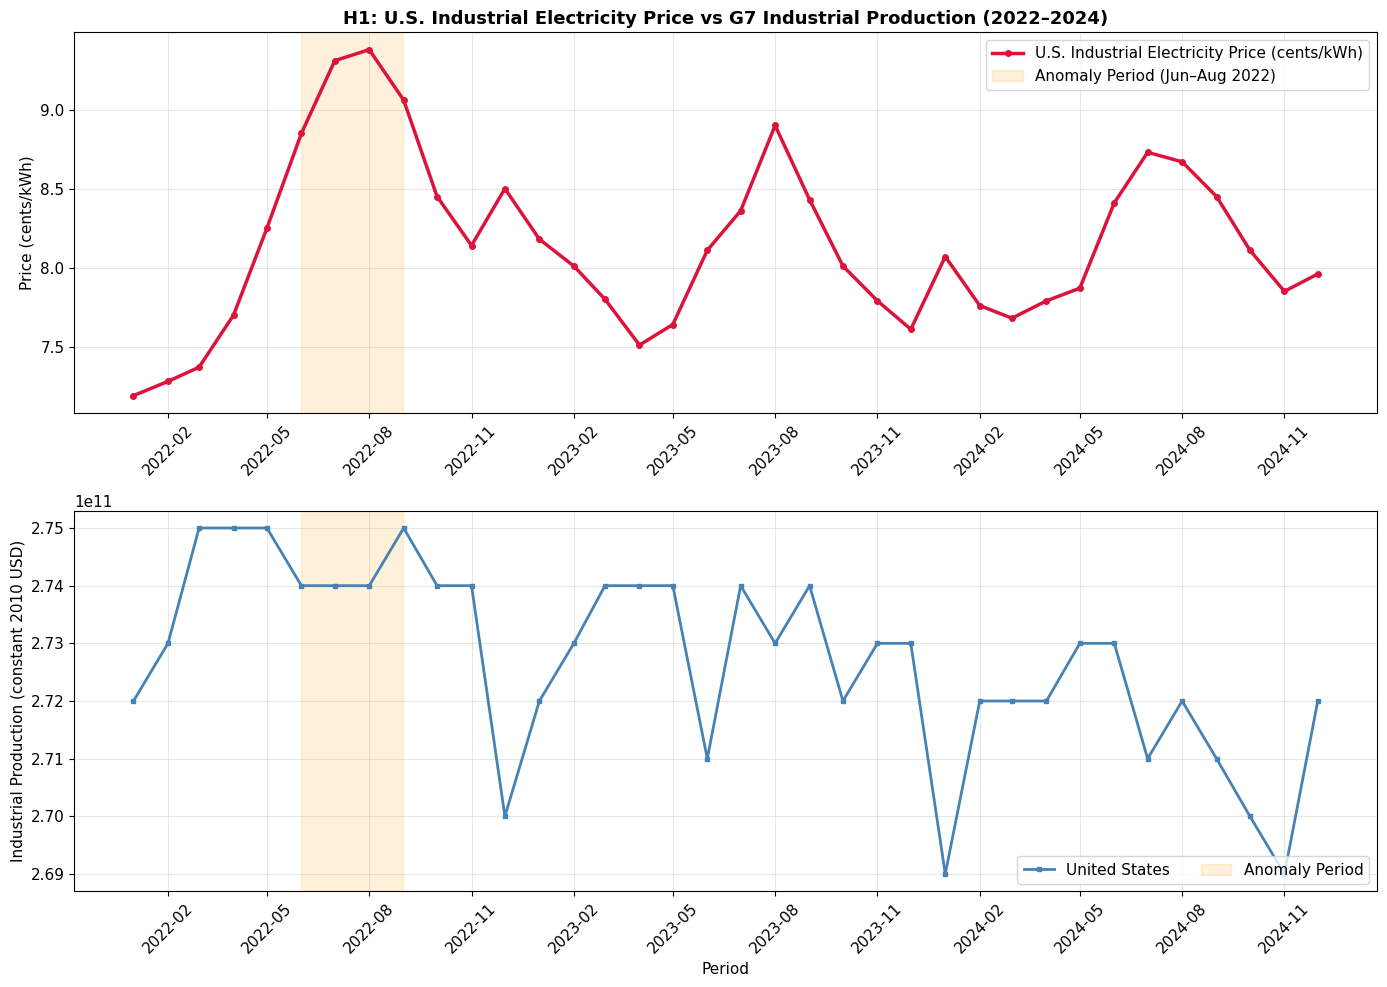

Plot H1 tersimpan di Reports/H1_timeseries.png


In [29]:
# Plot H1: Time-Series Overlay
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Harga listrik industri US
ax1 = axes[0]
ax1.plot(df_ind_price['period_dt'], df_ind_price['us_ind_price'],
         color='crimson', linewidth=2.5, marker='o', markersize=4,
         label='U.S. Industrial Electricity Price (cents/kWh)')
ax1.axvspan(pd.Timestamp('2022-06-01'), pd.Timestamp('2022-08-31'),
            alpha=0.15, color='orange', label='Anomaly Period (Jun–Aug 2022)')
ax1.set_ylabel('Price (cents/kWh)', fontsize=11)
ax1.set_title('H1: U.S. Industrial Electricity Price vs G7 Industrial Production (2022–2024)',
              fontsize=13, fontweight='bold')
ax1.legend(loc='upper right')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# Plot 2: Industrial Production G7
ax2 = axes[1]
country_labels = {'US': 'United States', 'DE': 'Germany',
                  'JP': 'Japan', 'GB': 'United Kingdom', 'FR': 'France'}
colors_g7 = ['steelblue', 'forestgreen', 'darkorange', 'purple', 'teal']

for i, country in enumerate(G7_COUNTRIES):
    df_c = df_ind_prod[df_ind_prod['country_code'] == country].sort_values('period_dt')
    if not df_c.empty:
        ax2.plot(df_c['period_dt'], df_c['industrial_prod_usd'],
                 linewidth=2, marker='s', markersize=3,
                 color=colors_g7[i], label=country_labels.get(country, country))

ax2.axvspan(pd.Timestamp('2022-06-01'), pd.Timestamp('2022-08-31'),
            alpha=0.15, color='orange', label='Anomaly Period')
ax2.set_ylabel('Industrial Production (constant 2010 USD)', fontsize=11)
ax2.set_xlabel('Period', fontsize=11)
ax2.legend(loc='lower right', ncol=3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('../Reports/H1_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot H1 tersimpan di Reports/H1_timeseries.png")

In [30]:
# Uji Korelasi H1
print("H1 - Pearson & Spearman Correlation")
print("Harga Listrik Industri US vs Industrial Production G7")

h1_results = []

for country in G7_COUNTRIES:
    df_c = df_ind_prod[df_ind_prod['country_code'] == country][['period', 'industrial_prod_usd']]
    df_merge = df_ind_price.merge(df_c, on='period', how='inner')
    df_merge = df_merge.dropna()

    if len(df_merge) < 5:
        print(f"{country}: data tidak cukup ({len(df_merge)} rows)")
        continue

    r_pearson, p_pearson   = pearsonr(df_merge['us_ind_price'], df_merge['industrial_prod_usd'])
    r_spearman, p_spearman = spearmanr(df_merge['us_ind_price'], df_merge['industrial_prod_usd'])

    significance = "***" if p_pearson < 0.001 else "**" if p_pearson < 0.01 else "*" if p_pearson < 0.05 else "ns"
    direction    = "negatif" if r_pearson < 0 else "positif"

    h1_results.append({
        'Country': country_labels.get(country, country),
        'N': len(df_merge),
        'Pearson r': round(r_pearson, 4),
        'p-value': round(p_pearson, 4),
        'Sig': significance,
        'Spearman r': round(r_spearman, 4),
        'Direction': direction
    })

    print(f"\n {country_labels.get(country, country):15}")
    print(f"  Pearson r  = {r_pearson:+.4f}  (p={p_pearson:.4f}) {significance}")
    print(f"  Spearman r = {r_spearman:+.4f}  (p={p_spearman:.4f})")
    print(f"  Arah korelasi: {direction}")

df_h1_result = pd.DataFrame(h1_results)

print("Table Summary of H1")
display(df_h1_result)

# Conclusion
neg_count = sum(1 for r in h1_results if r['Pearson r'] < 0)
sig_count = sum(1 for r in h1_results if r['Sig'] != 'ns')
print(f"\n Conclusion of H1:")
print(f"   {neg_count}/{len(h1_results)} negara G7 menunjukkan korelasi NEGATIF")
print(f"   {sig_count}/{len(h1_results)} negara G7 menunjukkan korelasi SIGNIFIKAN (p < 0.05)")
if neg_count >= 3 and sig_count >= 3:
    print("   -> H1 DIDUKUNG: Lonjakan harga listrik industri 2022 berjalan SEIRING")
    print("     penurunan Industrial Production G7")
else:
    print("   -> H1 TIDAK SEPENUHNYA DIDUKUNG: Pola korelasi tidak konsisten di semua negara G7")

H1 - Pearson & Spearman Correlation
Harga Listrik Industri US vs Industrial Production G7

 United States  
  Pearson r  = +0.0884  (p=0.6083) ns
  Spearman r = +0.0384  (p=0.8241)
  Arah korelasi: positif
DE: data tidak cukup (0 rows)
JP: data tidak cukup (0 rows)
GB: data tidak cukup (0 rows)
FR: data tidak cukup (0 rows)
Table Summary of H1


,Country,N,Pearson r,p-value,Sig,Spearman r,Direction
0,United States,36,0.0884,0.6083,ns,0.0384,positif



 Conclusion of H1:
   0/1 negara G7 menunjukkan korelasi NEGATIF
   0/1 negara G7 menunjukkan korelasi SIGNIFIKAN (p < 0.05)
   -> H1 TIDAK SEPENUHNYA DIDUKUNG: Pola korelasi tidak konsisten di semua negara G7


In [31]:
RAW_CSV_DIR = r"D:\Fir Document\Universitas Negeri Surabaya\Semester 4\Data Warehouse\Task\Final_Project\dwh-energy-project\data\raw_csv"

df_wb_ind_raw = pd.read_csv(os.path.join(RAW_CSV_DIR, "wb_industrial.csv"))

def parse_period_raw(p):
    p = str(p).strip()
    if "M" in p:
        parts = p.split("M")
        return f"{parts[0]}-{parts[1].zfill(2)}"
    else:
        return f"{int(float(p))}-01"

name_to_code = {
    "United States":  "US", "China":          "CN",
    "Germany":        "DE", "Japan":           "JP",
    "India":          "IN", "United Kingdom":  "GB",
    "France":         "FR", "Brazil":          "BR"
}

df_wb_ind_long = df_wb_ind_raw.melt(
    id_vars="period_raw",
    var_name="country_name",
    value_name="industrial_prod_usd"
)
df_wb_ind_long["period"]       = df_wb_ind_long["period_raw"].apply(parse_period_raw)
df_wb_ind_long["country_code"] = df_wb_ind_long["country_name"].map(name_to_code)
df_wb_ind_long = df_wb_ind_long[
    df_wb_ind_long["period"].between("2022-01", "2024-12")
].dropna(subset=["industrial_prod_usd", "country_code"]).reset_index(drop=True)

print("Data Industrial Production dari CSV:")
print(df_wb_ind_long.groupby("country_code")["industrial_prod_usd"].count())
print(f"\nTotal rows: {df_wb_ind_long.shape}")

Data Industrial Production dari CSV:
country_code
BR    36
CN    36
DE    36
FR    36
GB    36
IN    36
JP    36
US    36
Name: industrial_prod_usd, dtype: int64

Total rows: (288, 5)


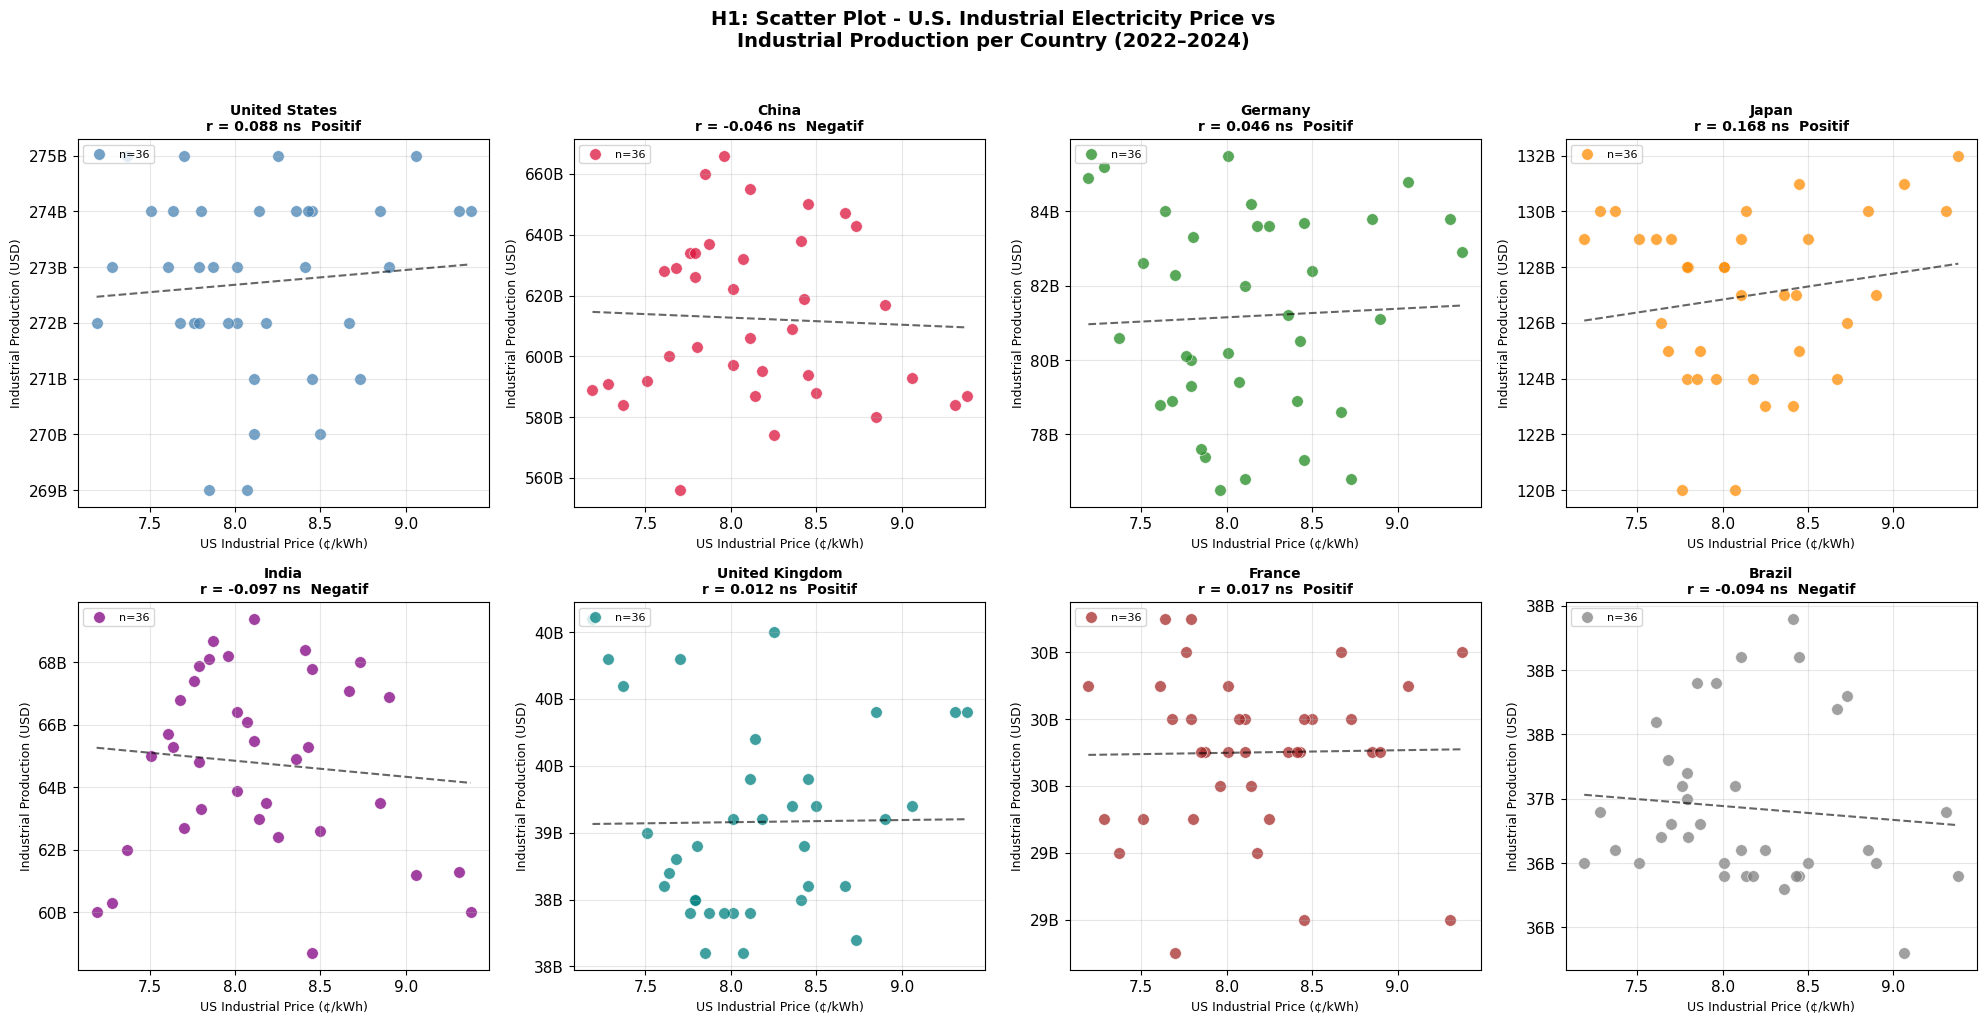

Table Summary H1 - Pearson Correlation per Country


,Country,N,Pearson r,p-value,Sig,Direction
0,United States,36,0.0884,0.6083,ns,Positif
1,China,36,-0.0463,0.7886,ns,Negatif
2,Germany,36,0.0459,0.7903,ns,Positif
3,Japan,36,0.1677,0.3283,ns,Positif
4,India,36,-0.0971,0.5731,ns,Negatif
5,United Kingdom,36,0.0123,0.9432,ns,Positif
6,France,36,0.0172,0.9206,ns,Positif
7,Brazil,36,-0.0936,0.5871,ns,Negatif



 Conclusion H1:
   3/8 negara menunjukkan korelasi NEGATIF
   0/8 negara menunjukkan korelasi SIGNIFIKAN (p<0.05)
   -> H1 SEBAGIAN DIDUKUNG


In [32]:
# Scatter Plot H1 - Semua Negara
ALL_COUNTRY_LABELS = {
    "US": "United States", "CN": "China",
    "DE": "Germany",       "JP": "Japan",
    "IN": "India",         "GB": "United Kingdom",
    "FR": "France",        "BR": "Brazil"
}
COUNTRIES_H1 = ["US", "CN", "DE", "JP", "IN", "GB", "FR", "BR"]
colors_h1    = ["steelblue","crimson","forestgreen","darkorange",
                "purple","teal","brown","gray"]

fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharey=False)
axes_flat  = axes.flatten()

h1_scatter_results = []

# df_wb_ind_long dan df_wb_cpi_long akan diisi oleh cell H1

for i, country in enumerate(COUNTRIES_H1):
    df_c = df_wb_ind_long[
        df_wb_ind_long["country_code"] == country
    ][["period", "industrial_prod_usd"]].copy()

    df_m = df_ind_price.merge(df_c, on="period", how="inner").dropna()

    ax = axes_flat[i]

    if df_m.empty or len(df_m) < 5:
        ax.text(0.5, 0.5, f"{ALL_COUNTRY_LABELS[country]}\nNo Data",
                ha="center", va="center", transform=ax.transAxes, fontsize=11)
        ax.set_title(ALL_COUNTRY_LABELS[country], fontsize=10, fontweight="bold")
        continue

    # Scatter
    ax.scatter(
        df_m["us_ind_price"],
        df_m["industrial_prod_usd"],
        alpha=0.75,
        color=colors_h1[i],
        edgecolors="white",
        linewidths=0.5,
        s=70,
        label=f"n={len(df_m)}"
    )

    # Regression line
    z_fit  = np.polyfit(df_m["us_ind_price"], df_m["industrial_prod_usd"], 1)
    p_fit  = np.poly1d(z_fit)
    x_line = np.linspace(df_m["us_ind_price"].min(),
                         df_m["us_ind_price"].max(), 100)
    ax.plot(x_line, p_fit(x_line), "--", color="black", alpha=0.6, linewidth=1.5)

    # Korelasi
    r, pval = pearsonr(df_m["us_ind_price"], df_m["industrial_prod_usd"])
    sig = ("***" if pval < 0.001 else
           "**"  if pval < 0.01  else
           "*"   if pval < 0.05  else "ns")
    direction = "Negatif" if r < 0 else "Positif"

    ax.set_title(
        f"{ALL_COUNTRY_LABELS[country]}\nr = {r:.3f} {sig}  {direction}",
        fontsize=10, fontweight="bold"
    )
    ax.set_xlabel("US Industrial Price (¢/kWh)", fontsize=9)
    ax.set_ylabel("Industrial Production (USD)", fontsize=9)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x/1e9:.0f}B")
    )
    ax.legend(fontsize=8, loc="upper left")

    h1_scatter_results.append({
        "Country":    ALL_COUNTRY_LABELS[country],
        "N":          len(df_m),
        "Pearson r":  round(r, 4),
        "p-value":    round(pval, 4),
        "Sig":        sig,
        "Direction":  direction
    })

fig.suptitle(
    "H1: Scatter Plot - U.S. Industrial Electricity Price vs\n"
    "Industrial Production per Country (2022–2024)",
    fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("../Reports/H1_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary Table
print("Table Summary H1 - Pearson Correlation per Country")
df_h1_scatter = pd.DataFrame(h1_scatter_results)
display(df_h1_scatter)

neg_count = sum(1 for r in h1_scatter_results if r["Pearson r"] < 0)
sig_count = sum(1 for r in h1_scatter_results if r["Sig"] != "ns")
print(f"\n Conclusion H1:")
print(f"   {neg_count}/{len(h1_scatter_results)} negara menunjukkan korelasi NEGATIF")
print(f"   {sig_count}/{len(h1_scatter_results)} negara menunjukkan korelasi SIGNIFIKAN (p<0.05)")
if neg_count >= 5 and sig_count >= 3:
    print("   -> H1 DIDUKUNG")
elif neg_count >= 3:
    print("   -> H1 SEBAGIAN DIDUKUNG")
else:
    print("   -> H1 TIDAK DIDUKUNG")

In [33]:
# Analisis Lanjutan H1: First Difference + Lag
print("H1 Advance - First Difference & Cross-Correlation dengan Lag")

lag_results = []

for country in COUNTRIES_H1:
    df_c = df_wb_ind_long[
        df_wb_ind_long["country_code"] == country
    ][["period", "industrial_prod_usd"]].copy()

    df_m = df_ind_price.merge(df_c, on="period").dropna().sort_values("period")

    if len(df_m) < 10:
        continue

    # Hitung perubahan % MoM (first difference)
    df_m["price_pct_chg"]  = df_m["us_ind_price"].pct_change() * 100
    df_m["indprod_pct_chg"] = df_m["industrial_prod_usd"].pct_change() * 100
    df_m = df_m.dropna()

    # Cross-correlation dengan lag 0, 1, 2, 3 bulan
    best_r, best_lag, best_p = 0, 0, 1
    for lag in [0, 1, 2, 3]:
        if lag == 0:
            x = df_m["price_pct_chg"]
            y = df_m["indprod_pct_chg"]
        else:
            x = df_m["price_pct_chg"].iloc[:-lag]
            y = df_m["indprod_pct_chg"].iloc[lag:]

        if len(x) < 5:
            continue

        r, p = pearsonr(x, y)
        if abs(r) > abs(best_r):
            best_r, best_lag, best_p = r, lag, p

    sig = ("***" if best_p < 0.001 else
           "**"  if best_p < 0.01  else
           "*"   if best_p < 0.05  else "ns")

    lag_results.append({
        "Country":  ALL_COUNTRY_LABELS[country],
        "Best Lag": f"{best_lag} bulan",
        "Best r":   round(best_r, 4),
        "p-value":  round(best_p, 4),
        "Sig":      sig,
        "Direction": "Negatif" if best_r < 0 else "Positif"
    })

df_lag = pd.DataFrame(lag_results)
display(df_lag)

neg_lag = sum(1 for r in lag_results if r["Best r"] < 0)
sig_lag = sum(1 for r in lag_results if r["Sig"] != "ns")

print(f"\nConclusion H1 (dengan lag adjustment):")
print(f"   {neg_lag}/{len(lag_results)} negara menunjukkan korelasi NEGATIF terkuat")
print(f"   {sig_lag}/{len(lag_results)} negara signifikan (p < 0.05)")
if neg_lag >= 5 and sig_lag >= 3:
    print("   -> H1 DIDUKUNG dengan lag adjustment")
elif neg_lag >= 3:
    print("   -> H1 SEBAGIAN DIDUKUNG dengan lag adjustment")
else:
    print("   -> H1 TETAP TIDAK DIDUKUNG meskipun dengan lag adjustment")

H1 Advance - First Difference & Cross-Correlation dengan Lag


,Country,Best Lag,Best r,p-value,Sig,Direction
0,United States,0 bulan,-0.3024,0.0774,ns,Negatif
1,China,1 bulan,0.1980,0.2618,ns,Positif
2,Germany,2 bulan,0.2174,0.2243,ns,Positif
3,Japan,2 bulan,0.3118,0.0773,ns,Positif
4,India,3 bulan,-0.2449,0.1767,ns,Negatif
5,United Kingdom,3 bulan,-0.1771,0.3321,ns,Negatif
6,France,0 bulan,0.1023,0.5589,ns,Positif
7,Brazil,1 bulan,-0.2588,0.1394,ns,Negatif



Conclusion H1 (dengan lag adjustment):
   4/8 negara menunjukkan korelasi NEGATIF terkuat
   0/8 negara signifikan (p < 0.05)
   -> H1 SEBAGIAN DIDUKUNG dengan lag adjustment


---
# H2 - Harga Listrik Retail AS vs CPI Global

**Hipotesis:** Harga listrik retail AS berkorelasi positif dengan CPI global setelah dikontrol variabel eksogen.

**Metode:** Pearson Correlation + Rolling Correlation (12-bulan) + OLS Regression

In [34]:
# Load CPI dari CSV Lokal
df_wb_cpi_raw = pd.read_csv(os.path.join(RAW_CSV_DIR, "wb_cpi.csv"))

df_wb_cpi_long = df_wb_cpi_raw.melt(
    id_vars="period_raw",
    var_name="country_name",
    value_name="cpi_pct_yoy"
)
df_wb_cpi_long["period"]       = df_wb_cpi_long["period_raw"].apply(parse_period_raw)
df_wb_cpi_long["country_code"] = df_wb_cpi_long["country_name"].map(name_to_code)
df_wb_cpi_long = df_wb_cpi_long[
    df_wb_cpi_long["period"].between("2022-01", "2024-12")
].dropna(subset=["cpi_pct_yoy", "country_code"]).reset_index(drop=True)

colors_h2 = ["steelblue","crimson","forestgreen","darkorange",
             "purple","teal","brown","gray"]

print("Data CPI dari CSV:")
print(df_wb_cpi_long.groupby("country_code")["cpi_pct_yoy"].count())

Data CPI dari CSV:
country_code
BR    36
CN    36
DE    36
FR    36
GB    36
IN    36
JP    36
US    36
Name: cpi_pct_yoy, dtype: int64


In [35]:
df_cpi_check = pd.read_sql("""
    SELECT country_code, 
           COUNT(*) as total_rows,
           COUNT(cpi_pct_yoy) as non_null_rows,
           MIN(period) as period_min,
           MAX(period) as period_max,
           ROUND(AVG(cpi_pct_yoy)::numeric, 4) as avg_cpi
    FROM fact_energy_economy
    WHERE sector_id = 'ALL'
    GROUP BY country_code
    ORDER BY country_code
""", engine)

print("Check CPI Data Per Country at Supabase")
display(df_cpi_check)

# Cek retail price US
df_price_check = pd.read_sql("""
    SELECT sector_id,
           COUNT(*) as rows,
           MIN(period) as min_period,
           MAX(period) as max_period,
           ROUND(AVG(price_cents_kwh)::numeric, 4) as avg_price
    FROM fact_energy_economy
    WHERE country_code = 'US'
    GROUP BY sector_id
    ORDER BY sector_id
""", engine)

print("\nCheck Retail Data Price US per Sector")
display(df_price_check)

Check CPI Data Per Country at Supabase


,country_code,total_rows,non_null_rows,period_min,period_max,avg_cpi
0,US,36,36,2022-01,2024-12,5.0329



Check Retail Data Price US per Sector


,sector_id,rows,min_period,max_period,avg_price
0,ALL,36,2022-01,2024-12,12.6197
1,COM,36,2022-01,2024-12,12.5522
2,IND,36,2022-01,2024-12,8.1439
3,RES,36,2022-01,2024-12,15.8517


In [36]:
# Load CPI dari CSV Local
df_wb_cpi = pd.read_csv(os.path.join(RAW_CSV_DIR, "wb_cpi.csv"))

df_wb_cpi_long = df_wb_cpi.melt(
    id_vars="period_raw",
    var_name="country_name",
    value_name="cpi_pct_yoy"
)
df_wb_cpi_long["period"]       = df_wb_cpi_long["period_raw"].apply(parse_period_raw)
df_wb_cpi_long["country_code"] = df_wb_cpi_long["country_name"].map(name_to_code)

# Filter 2022–2024
df_wb_cpi_long = df_wb_cpi_long[
    df_wb_cpi_long["period"].between("2022-01", "2024-12")
].dropna(subset=["cpi_pct_yoy", "country_code"]).reset_index(drop=True)

print("Data CPI dari CSV:")
print(df_wb_cpi_long.groupby("country_code")["cpi_pct_yoy"].count())
print(f"\nSample data:")
print(df_wb_cpi_long.head(3))

Data CPI dari CSV:
country_code
BR    36
CN    36
DE    36
FR    36
GB    36
IN    36
JP    36
US    36
Name: cpi_pct_yoy, dtype: int64

Sample data:
  period_raw   country_name  cpi_pct_yoy   period country_code
0    2022M01  United States     7.558806  2022-01           US
1    2022M02  United States     7.937279  2022-02           US
2    2022M03  United States     8.572205  2022-03           US


In [37]:
# Load Retail Price US dari Supabase
df_retail_price = pd.read_sql("""
    SELECT period, price_cents_kwh
    FROM fact_energy_economy
    WHERE country_code = 'US'
      AND sector_id    = 'ALL'
    ORDER BY period
""", engine)

df_retail_price["period_dt"]   = pd.to_datetime(df_retail_price["period"] + "-01")
df_retail_price = df_retail_price.rename(
    columns={"price_cents_kwh": "us_retail_price"}
).sort_values("period_dt").reset_index(drop=True)

print(f"Retail Price US: {df_retail_price.shape}")
print(df_retail_price.head(3))

Retail Price US: (36, 3)
    period  us_retail_price  period_dt
0  2022-01            11.24 2022-01-01
1  2022-02            11.42 2022-02-01
2  2022-03            11.48 2022-03-01


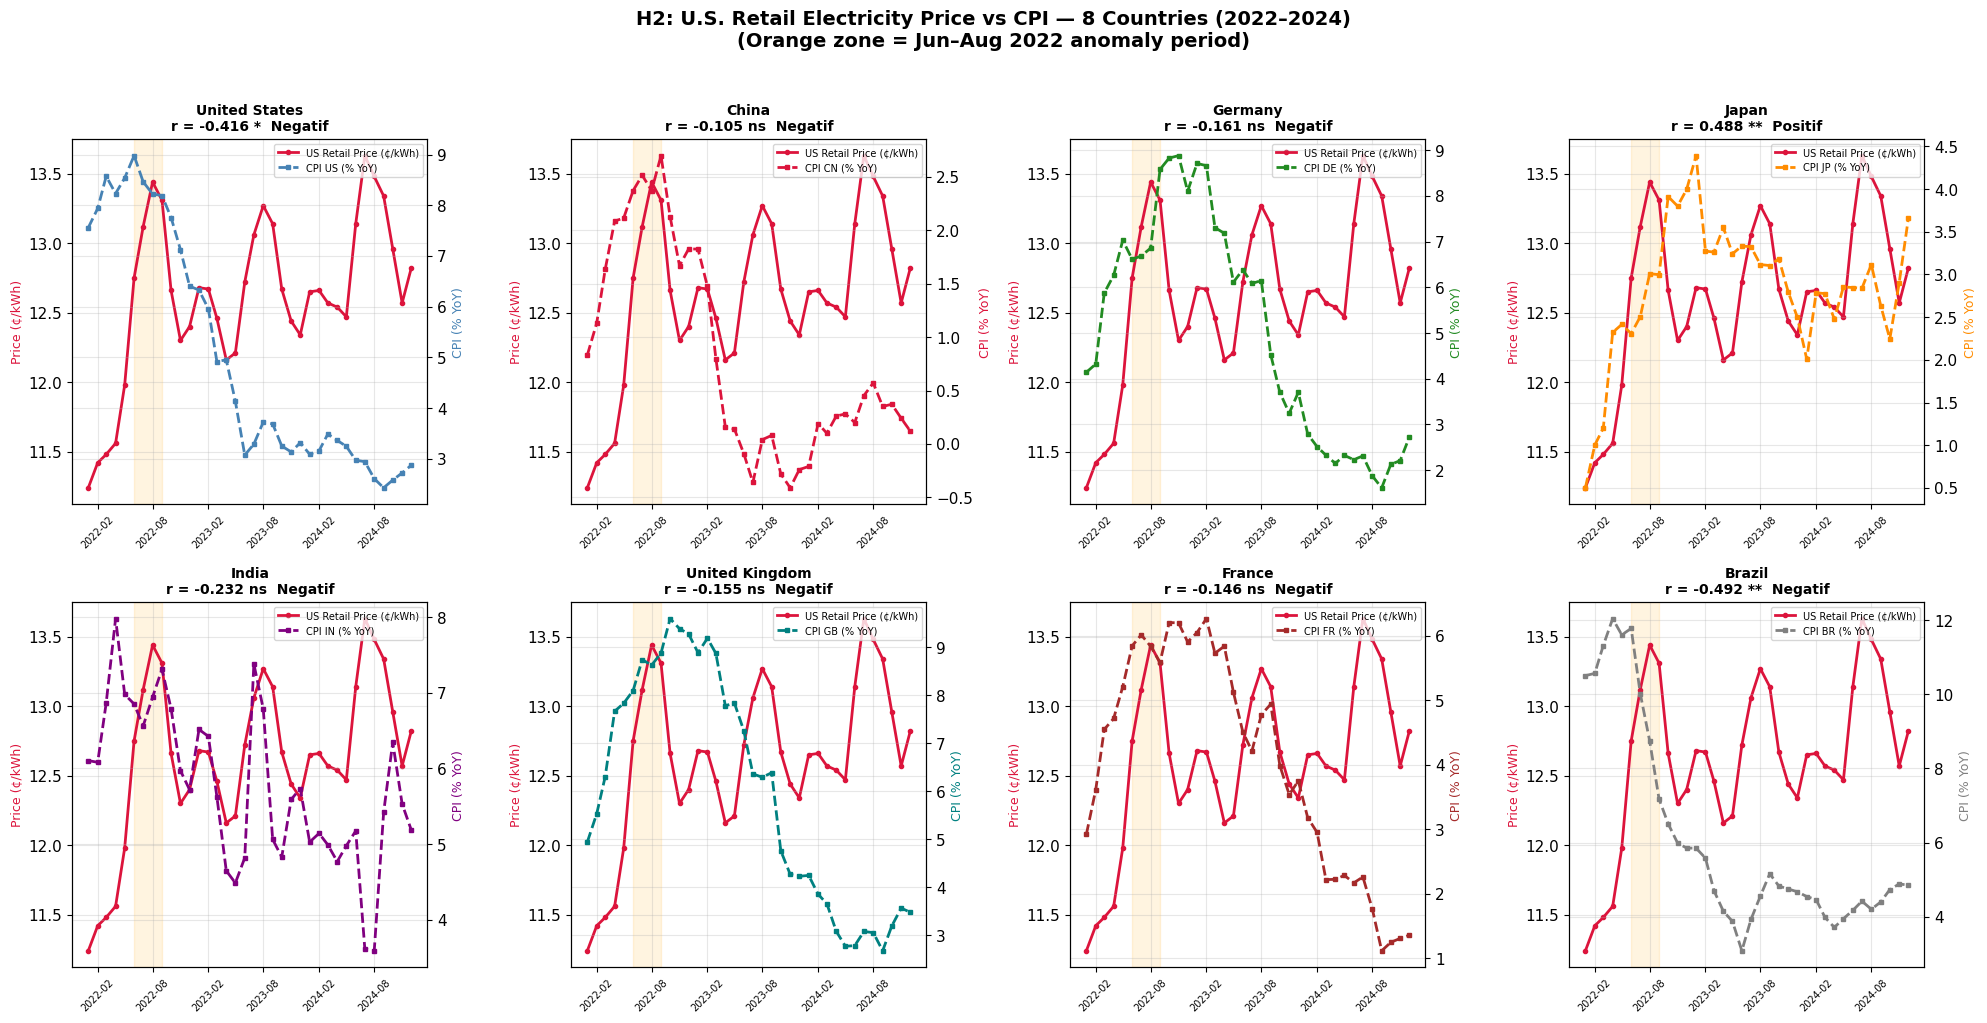

TABEL RINGKASAN H2 - US Retail Price vs CPI Global


,Country,N,Pearson r,p-value,Sig,Direction
0,United States,36,-0.4161,0.0116,*,Negatif
1,China,36,-0.1054,0.5409,ns,Negatif
2,Germany,36,-0.1609,0.3486,ns,Negatif
3,Japan,36,0.4883,0.0025,**,Positif
4,India,36,-0.2320,0.1733,ns,Negatif
5,United Kingdom,36,-0.1546,0.3679,ns,Negatif
6,France,36,-0.1455,0.3970,ns,Negatif
7,Brazil,36,-0.4924,0.0023,**,Negatif



 Conclusion of H2:
   1/8 negara menunjukkan korelasi POSITIF
   3/8 negara menunjukkan korelasi SIGNIFIKAN (p<0.05)
   -> H2 TIDAK DIDUKUNG


In [38]:
# H2: Korelasi Retail Price vs CPI per Negara
ALL_COUNTRIES = ["US", "CN", "DE", "JP", "IN", "GB", "FR", "BR"]
country_full  = {
    "US": "United States", "CN": "China",
    "DE": "Germany",       "JP": "Japan",
    "IN": "India",         "GB": "United Kingdom",
    "FR": "France",        "BR": "Brazil"
}
colors_h2 = ["steelblue","crimson","forestgreen","darkorange",
             "purple","teal","brown","gray"]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes_flat  = axes.flatten()
h2_results = []

for i, country in enumerate(ALL_COUNTRIES):
    df_c = df_wb_cpi_long[
        df_wb_cpi_long["country_code"] == country
    ][["period", "cpi_pct_yoy"]].copy()

    df_m = df_retail_price.merge(df_c, on="period", how="inner").dropna()
    df_m = df_m.sort_values("period_dt").reset_index(drop=True)

    ax  = axes_flat[i]
    ax2 = ax.twinx()

    if len(df_m) < 5:
        ax.text(0.5, 0.5, "No Data", ha="center", va="center",
                transform=ax.transAxes)
        continue

    # Plot harga listrik
    ax.plot(df_m["period_dt"], df_m["us_retail_price"],
            color="crimson", linewidth=2, marker="o", markersize=3,
            label="US Retail Price (¢/kWh)")

    # Plot CPI
    ax2.plot(df_m["period_dt"], df_m["cpi_pct_yoy"],
             color=colors_h2[i], linewidth=2, linestyle="--",
             marker="s", markersize=3, label=f"CPI {country} (% YoY)")

    # Anomaly zone
    ax.axvspan(pd.Timestamp("2022-06-01"), pd.Timestamp("2022-08-31"),
               alpha=0.12, color="orange")

    # Korelasi
    r, pval = pearsonr(df_m["us_retail_price"], df_m["cpi_pct_yoy"])
    sig     = ("***" if pval < 0.001 else
               "**"  if pval < 0.01  else
               "*"   if pval < 0.05  else "ns")
    direction = "Positif" if r > 0 else "Negatif"

    ax.set_title(
        f"{country_full[country]}\nr = {r:.3f} {sig}  {direction}",
        fontsize=10, fontweight="bold"
    )
    ax.set_ylabel("Price (¢/kWh)", color="crimson", fontsize=9)
    ax2.set_ylabel("CPI (% YoY)", color=colors_h2[i], fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, fontsize=7)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2,
              loc="upper right", fontsize=7)

    h2_results.append({
        "Country":   country_full[country],
        "N":         len(df_m),
        "Pearson r": round(r, 4),
        "p-value":   round(pval, 4),
        "Sig":       sig,
        "Direction": direction
    })

fig.suptitle(
    "H2: U.S. Retail Electricity Price vs CPI — 8 Countries (2022–2024)\n"
    "(Orange zone = Jun–Aug 2022 anomaly period)",
    fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("../Reports/H2_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()

# Tabel ringkasan
print("TABEL RINGKASAN H2 - US Retail Price vs CPI Global")
df_h2 = pd.DataFrame(h2_results)
display(df_h2)

pos_count = sum(1 for r in h2_results if r["Pearson r"] > 0)
sig_count = sum(1 for r in h2_results if r["Sig"] != "ns")

print(f"\n Conclusion of H2:")
print(f"   {pos_count}/{len(h2_results)} negara menunjukkan korelasi POSITIF")
print(f"   {sig_count}/{len(h2_results)} negara menunjukkan korelasi SIGNIFIKAN (p<0.05)")
if pos_count >= 5 and sig_count >= 4:
    print("   -> H2 DIDUKUNG")
elif pos_count >= 5 and sig_count >= 2:
    print("   -> H2 SEBAGIAN DIDUKUNG")
else:
    print("   -> H2 TIDAK DIDUKUNG")

In [39]:
# OLS Regression H2 - US Price ~ US CPI
df_us_h2 = df_retail_price.merge(
    df_wb_cpi_long[df_wb_cpi_long["country_code"] == "US"][["period", "cpi_pct_yoy"]],
    on="period"
).dropna()

X = sm.add_constant(df_us_h2["cpi_pct_yoy"])
y = df_us_h2["us_retail_price"]
ols = sm.OLS(y, X).fit()

print("OLS REGRESSION - US Retail Price ~ US CPI")
print(ols.summary())
print(f"\nInterpretasi:")
print(f"  R²      = {ols.rsquared:.4f} -> {ols.rsquared*100:.1f}% variansi price dijelaskan oleh CPI")
print(f"  Koef    = {ols.params['cpi_pct_yoy']:.4f}; setiap CPI naik 1%, price naik {ols.params['cpi_pct_yoy']:.4f} ¢/kWh")
print(f"  p-value = {ols.pvalues['cpi_pct_yoy']:.4f}")

OLS REGRESSION - US Retail Price ~ US CPI
                            OLS Regression Results                            
Dep. Variable:        us_retail_price   R-squared:                       0.173
Model:                            OLS   Adj. R-squared:                  0.149
Method:                 Least Squares   F-statistic:                     7.118
Date:                Mon, 25 May 2026   Prob (F-statistic):             0.0116
Time:                        16:18:57   Log-Likelihood:                -27.745
No. Observations:                  36   AIC:                             59.49
Df Residuals:                      34   BIC:                             62.66
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const   

---
# H3 - Bauran Energi AS vs Volatilitas CPI

**Hipotesis:** Bauran energi AS mengalami pergeseran struktural 2022–2024 yang berkorelasi negatif dengan volatilitas CPI.

**Metode:** Proporsi Renewable per Tahun + Korelasi Negatif dengan CPI Volatility (std rolling)

In [40]:
# Proporsi Renewable dari total generation per bulan
df_gen_h3 = fact_gen.copy()
df_gen_h3['period_dt'] = pd.to_datetime(df_gen_h3['period'] + '-01')

# Total generation per periode
df_total = df_gen_h3.groupby('period')['net_generation_mwh'].sum().reset_index()
df_total = df_total.rename(columns={'net_generation_mwh': 'total_gen'})

# Renewable generation per periode
df_renew = df_gen_h3[df_gen_h3['is_renewable'] == True].groupby('period')['net_generation_mwh'].sum().reset_index()
df_renew = df_renew.rename(columns={'net_generation_mwh': 'renew_gen'})

# Fossil generation per periode
df_fossil = df_gen_h3[df_gen_h3['fuel_category'] == 'Fossil'].groupby('period')['net_generation_mwh'].sum().reset_index()
df_fossil = df_fossil.rename(columns={'net_generation_mwh': 'fossil_gen'})

df_mix = df_total.merge(df_renew, on='period', how='left')
df_mix = df_mix.merge(df_fossil, on='period', how='left')
df_mix['renew_share']  = df_mix['renew_gen']  / df_mix['total_gen'] * 100
df_mix['fossil_share'] = df_mix['fossil_gen'] / df_mix['total_gen'] * 100
df_mix['period_dt']    = pd.to_datetime(df_mix['period'] + '-01')
df_mix = df_mix.sort_values('period_dt').reset_index(drop=True)

# CPI volatility (rolling std 6 bulan) untuk US
df_cpi_us = fact_ee[
    (fact_ee['sector_id'] == 'ALL') &
    (fact_ee['country_code'] == 'US')
][['period', 'cpi_pct_yoy']].dropna().sort_values('period')
df_cpi_us['cpi_volatility'] = df_cpi_us['cpi_pct_yoy'].rolling(6).std()

# Merge
df_h3 = df_mix.merge(df_cpi_us[['period', 'cpi_pct_yoy', 'cpi_volatility']], on='period', how='left')

print(f"Data H3 siap: {df_h3.shape}")
print(df_h3[['period', 'renew_share', 'fossil_share', 'cpi_pct_yoy', 'cpi_volatility']].head(6))

Data H3 siap: (36, 9)
    period  renew_share  fossil_share  cpi_pct_yoy  cpi_volatility
0  2022-01    15.564893     64.894858     7.558806             NaN
1  2022-02    16.693988     62.984782     7.937279             NaN
2  2022-03    19.344291     59.656322     8.572205             NaN
3  2022-04    18.515943     61.222514     8.231751             NaN
4  2022-05    17.183027     62.845395     8.538171             NaN
5  2022-06    15.558762     66.410501     8.979361        0.505548


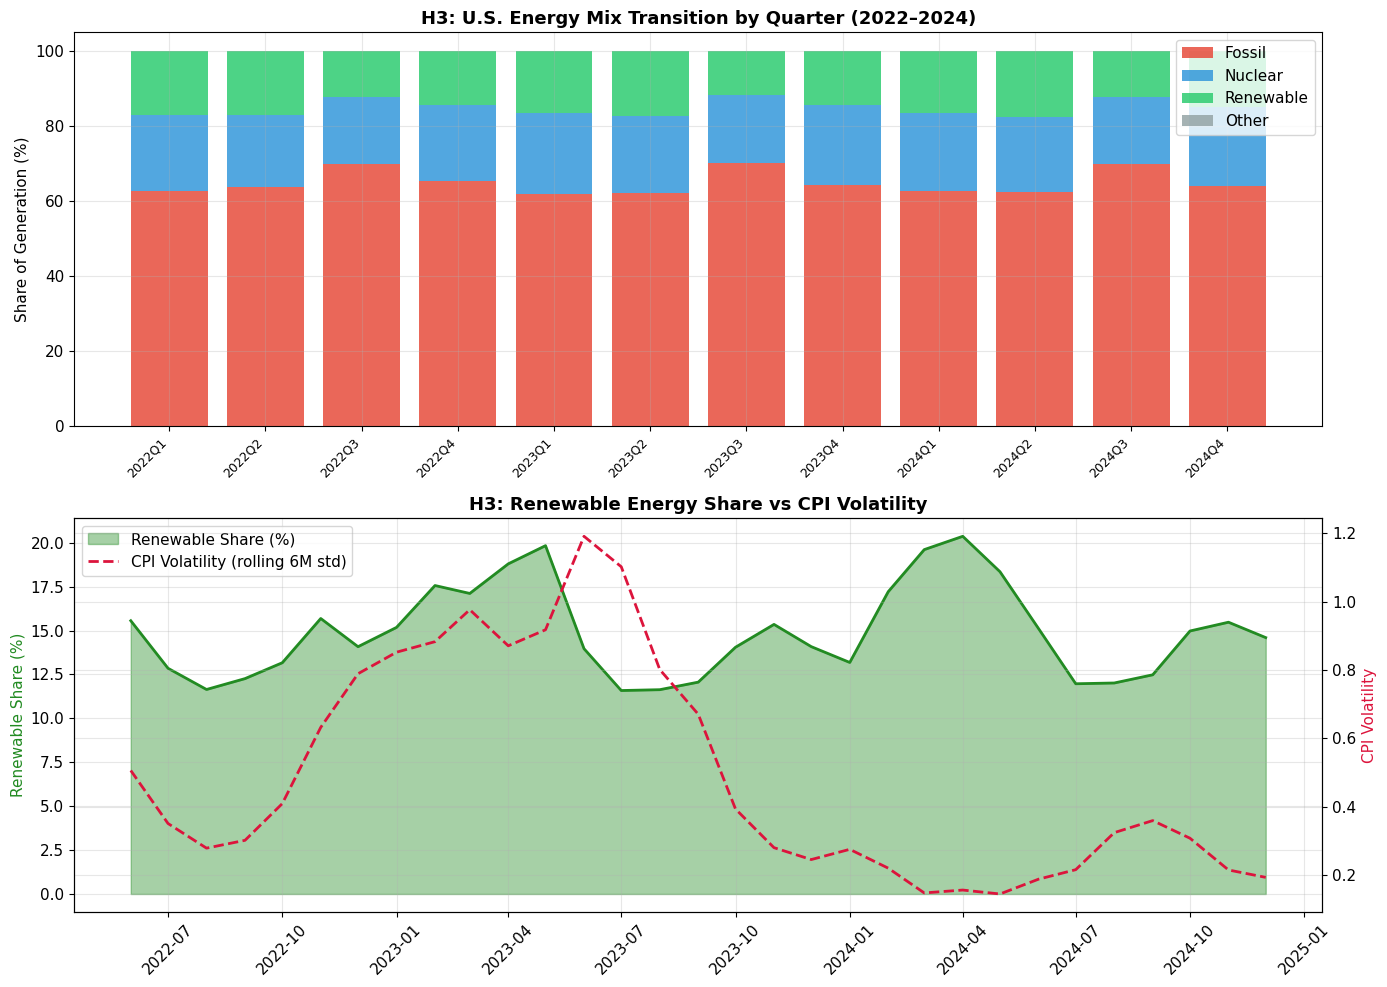

In [41]:
# Plot H3: Stacked Area + CPI Volatility
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Stacked bar proporsi bauran energi per kuartal
ax1 = axes[0]

# Agregasi per kuartal
df_gen_q = df_gen_h3.copy()
df_gen_q['quarter'] = df_gen_q['period_dt'].dt.to_period('Q').astype(str)
df_pivot  = df_gen_q.groupby(['quarter', 'fuel_category'])['net_generation_mwh'].sum().unstack(fill_value=0)
df_pivot_pct = df_pivot.div(df_pivot.sum(axis=1), axis=0) * 100

cat_colors = {'Fossil': '#e74c3c', 'Renewable': '#2ecc71', 'Nuclear': '#3498db', 'Other': '#95a5a6'}
bottom = np.zeros(len(df_pivot_pct))
x_pos  = range(len(df_pivot_pct))

for cat in ['Fossil', 'Nuclear', 'Renewable', 'Other']:
    if cat in df_pivot_pct.columns:
        ax1.bar(x_pos, df_pivot_pct[cat], bottom=bottom,
                label=cat, color=cat_colors.get(cat, 'gray'), alpha=0.85)
        bottom += df_pivot_pct[cat].values

ax1.set_xticks(x_pos)
ax1.set_xticklabels(df_pivot_pct.index, rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('Share of Generation (%)', fontsize=11)
ax1.set_title('H3: U.S. Energy Mix Transition by Quarter (2022–2024)',
              fontsize=13, fontweight='bold')
ax1.legend(loc='upper right')
ax1.set_ylim(0, 105)

# Plot 2: Renewable Share vs CPI Volatility
ax2  = axes[1]
ax2b = ax2.twinx()

df_h3_clean = df_h3.dropna(subset=['cpi_volatility'])
ax2.fill_between(df_h3_clean['period_dt'], df_h3_clean['renew_share'],
                 alpha=0.4, color='forestgreen', label='Renewable Share (%)')
ax2.plot(df_h3_clean['period_dt'], df_h3_clean['renew_share'],
         color='forestgreen', linewidth=2)
ax2b.plot(df_h3_clean['period_dt'], df_h3_clean['cpi_volatility'],
          color='crimson', linewidth=2, linestyle='--', label='CPI Volatility (rolling 6M std)')

ax2.set_ylabel('Renewable Share (%)', color='forestgreen', fontsize=11)
ax2b.set_ylabel('CPI Volatility', color='crimson', fontsize=11)
ax2.set_title('H3: Renewable Energy Share vs CPI Volatility',
              fontsize=13, fontweight='bold')

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('../Reports/H3_energy_mix.png', dpi=150, bbox_inches='tight')
plt.show()

In [42]:
# Uji Korelasi H3
df_h3_corr = df_h3.dropna(subset=['renew_share', 'cpi_volatility', 'cpi_pct_yoy'])

r_renew_vol,  p_renew_vol  = pearsonr(df_h3_corr['renew_share'], df_h3_corr['cpi_volatility'])
r_renew_cpi,  p_renew_cpi  = pearsonr(df_h3_corr['renew_share'], df_h3_corr['cpi_pct_yoy'])
r_fossil_vol, p_fossil_vol = pearsonr(df_h3_corr['fossil_share'], df_h3_corr['cpi_volatility'])

print("H3 - Correlation Results")
print(f"   Renewable Share vs CPI Volatility : r={r_renew_vol:+.4f}  p={p_renew_vol:.4f}")
print(f"   Renewable Share vs CPI (% YoY)    : r={r_renew_cpi:+.4f}  p={p_renew_cpi:.4f}")
print(f"   Fossil Share vs CPI Volatility     : r={r_fossil_vol:+.4f}  p={p_fossil_vol:.4f}")

# Perubahan proporsi tahunan
print("\n")
print("Pergeseran Structural : Proporsi Bauran Energi per Tahun")
df_h3['year'] = df_h3['period_dt'].dt.year
yearly_mix    = df_h3.groupby('year')[['renew_share', 'fossil_share']].mean().round(2)
display(yearly_mix)

renew_change = yearly_mix['renew_share'].iloc[-1] - yearly_mix['renew_share'].iloc[0]
fossil_change = yearly_mix['fossil_share'].iloc[-1] - yearly_mix['fossil_share'].iloc[0]

print(f"\nConclusion for H3:")
print(f"   Perubahan Renewable Share 2022 - 2024 : {renew_change:+.2f}%")
print(f"   Perubahan Fossil Share 2022 - 2024    : {fossil_change:+.2f}%")
print(f"   Korelasi Renewable vs CPI Volatility: r={r_renew_vol:+.4f}")
if r_renew_vol < 0 and p_renew_vol < 0.05 and renew_change > 0:
    print("   -> H3 DIDUKUNG: Renewable share naik dan berkorelasi NEGATIF dengan CPI volatility")
elif renew_change > 0:
    print("   -> H3 SEBAGIAN DIDUKUNG: Renewable share naik tapi korelasi dengan CPI volatility tidak signifikan")
else:
    print("   -> H3 TIDAK DIDUKUNG")

H3 - Correlation Results
   Renewable Share vs CPI Volatility : r=-0.0061  p=0.9742
   Renewable Share vs CPI (% YoY)    : r=-0.1056  p=0.5717
   Fossil Share vs CPI Volatility     : r=+0.0074  p=0.9686


Pergeseran Structural : Proporsi Bauran Energi per Tahun


,renew_share,fossil_share
year,,
2022,15.21,65.29
2023,15.10,64.43
2024,15.44,64.58



Conclusion for H3:
   Perubahan Renewable Share 2022 - 2024 : +0.23%
   Perubahan Fossil Share 2022 - 2024    : -0.71%
   Korelasi Renewable vs CPI Volatility: r=-0.0061
   -> H3 SEBAGIAN DIDUKUNG: Renewable share naik tapi korelasi dengan CPI volatility tidak signifikan


---
# H4 - Deteksi Anomali Simultan Juni - Agustus 2022

**Hipotesis:** Juni - Agustus 2022 adalah periode anomali simultan di semua indikator (Z-score > 2.0).

**Metode:** Z-Score standardization + Multi-indicator anomaly detection + Heatmap

In [43]:
df_us = fact_ee[
    (fact_ee['sector_id'] == 'ALL') &
    (fact_ee['country_code'] == 'US')
].copy()
df_us = df_us.sort_values('period_dt').reset_index(drop=True)

# Indikator yang akan dianalisis anomalinya
INDICATORS = {
    'price_cents_kwh':    'US Retail Price (¢/kWh)',
    'cpi_pct_yoy':        'US CPI (% YoY)',
    'industrial_prod_usd': 'Industrial Production',
    'unemployment_rate':  'Unemployment Rate',
}

INDICATORS = {k: v for k, v in INDICATORS.items()
              if k in df_us.columns and df_us[k].notna().sum() > 10}

print(f"Indikator yang dianalisis: {list(INDICATORS.keys())}")

# Hitung Z-score untuk setiap indikator
df_zscore = df_us[['period', 'period_dt']].copy()

for col in INDICATORS.keys():
    series = df_us[col].fillna(df_us[col].mean())
    df_zscore[f'z_{col}'] = stats.zscore(series)

# Z-score absolut > 2.0
z_cols = [f'z_{c}' for c in INDICATORS.keys()]
df_zscore['max_abs_zscore'] = df_zscore[z_cols].abs().max(axis=1)
df_zscore['n_anomaly_indicators'] = (df_zscore[z_cols].abs() > 2.0).sum(axis=1)
df_zscore['is_simultaneous_anomaly'] = df_zscore['n_anomaly_indicators'] >= max(2, len(INDICATORS) // 2)

df_zscore['is_target_period'] = (
    (df_zscore['period_dt'] >= '2022-06-01') &
    (df_zscore['period_dt'] <= '2022-08-31')
)

print(f"\nPeriode anomali simultan terdeteksi:")
anomaly_periods = df_zscore[df_zscore['is_simultaneous_anomaly']]
print(anomaly_periods[['period', 'n_anomaly_indicators', 'max_abs_zscore']].to_string(index=False))

Indikator yang dianalisis: ['price_cents_kwh', 'cpi_pct_yoy', 'industrial_prod_usd', 'unemployment_rate']

Periode anomali simultan terdeteksi:
Empty DataFrame
Columns: [period, n_anomaly_indicators, max_abs_zscore]
Index: []


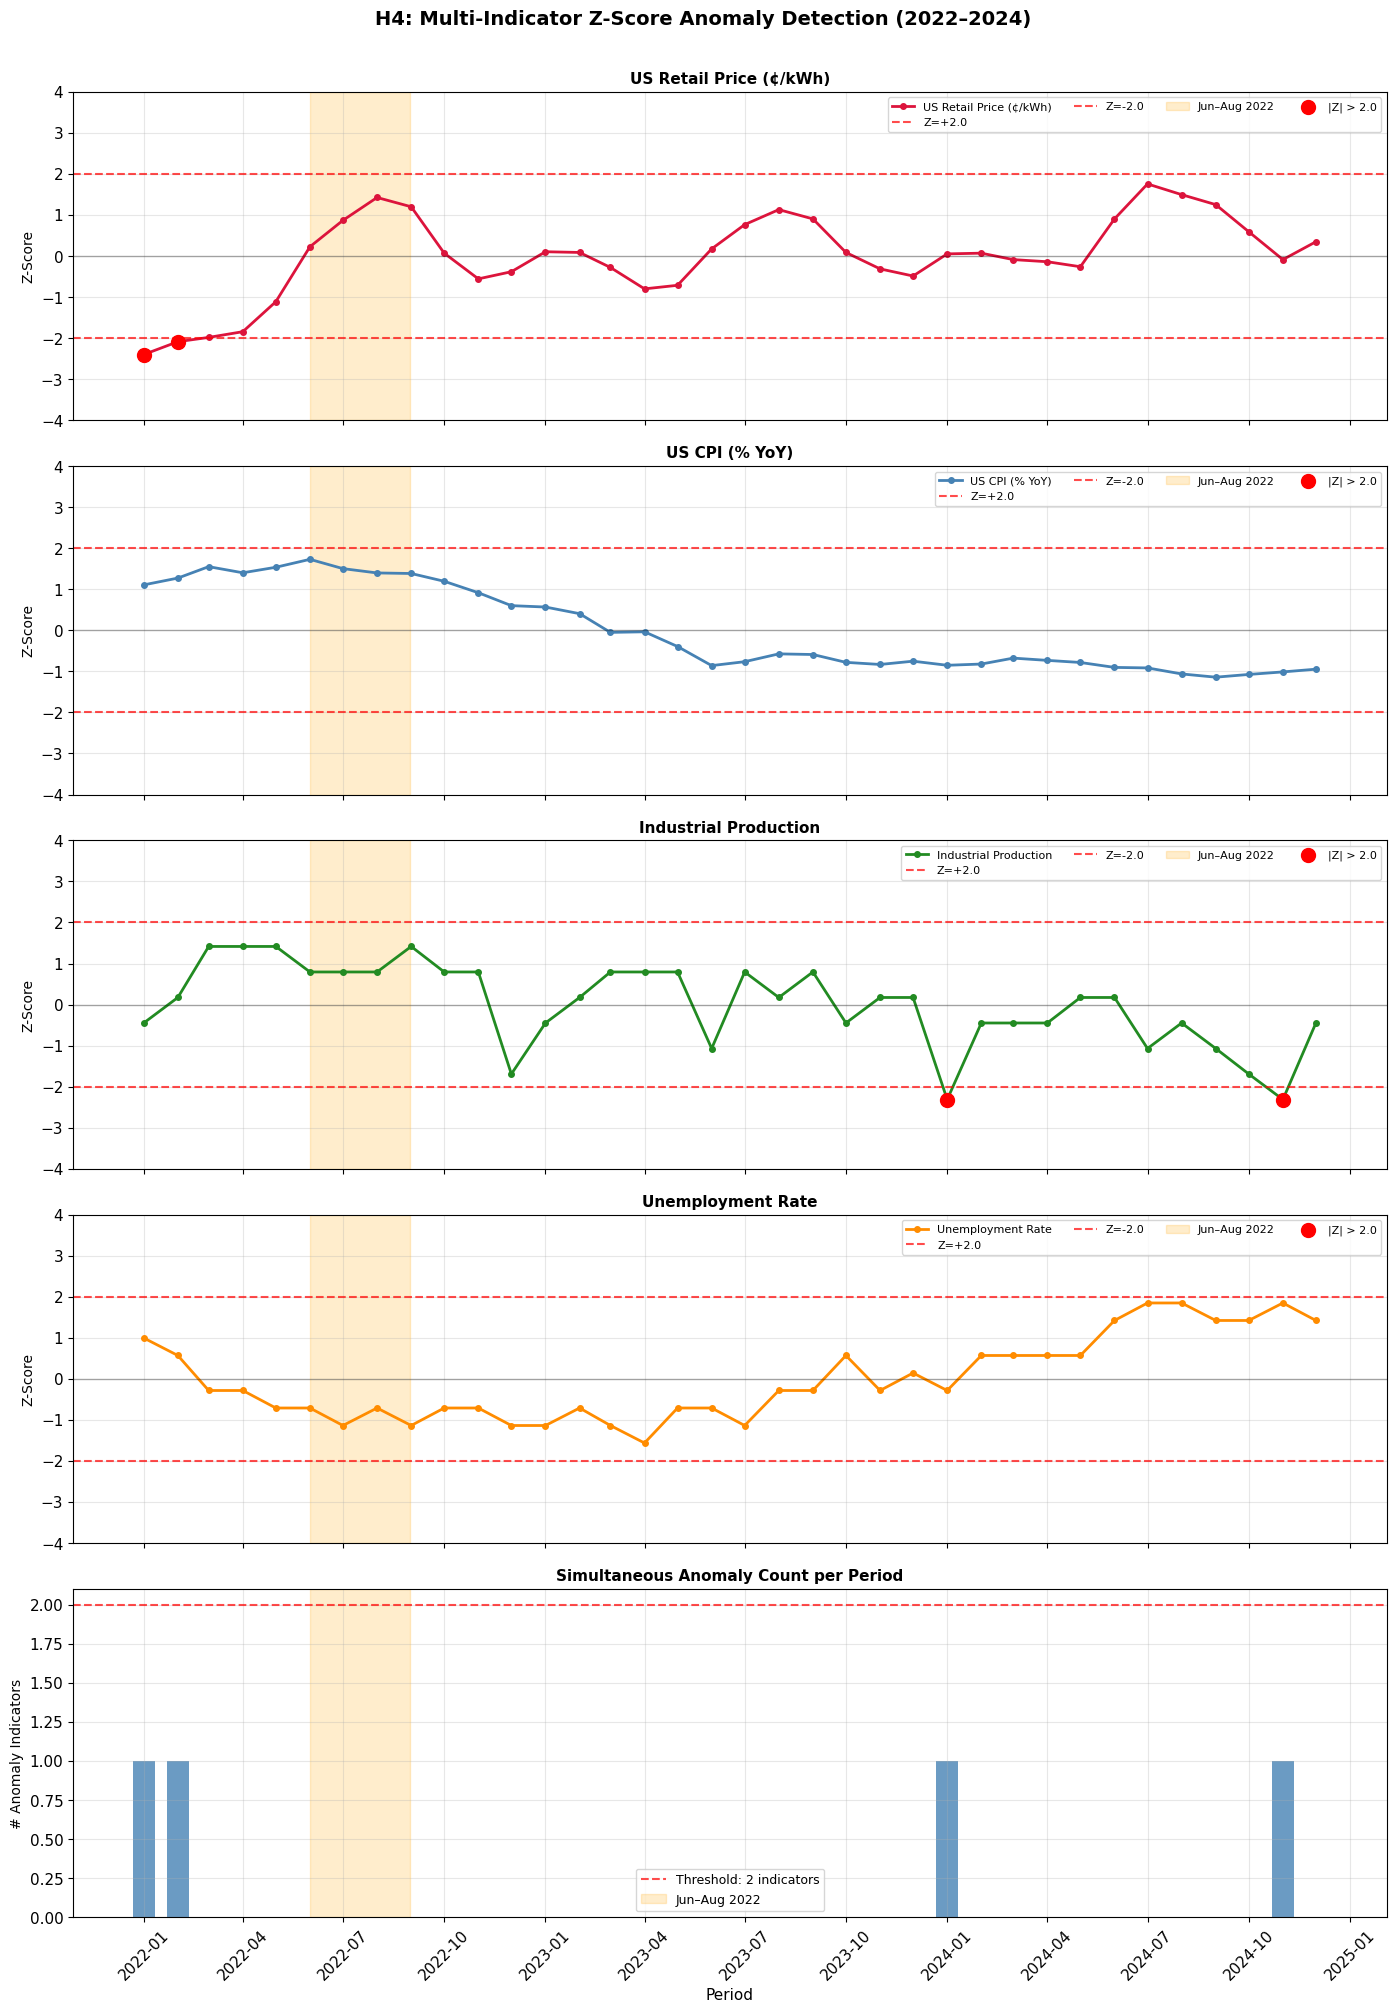

In [44]:
# Plot H4: Z-Score Multi-Indicator
fig, axes = plt.subplots(len(INDICATORS) + 1, 1,
                         figsize=(14, 4 * (len(INDICATORS) + 1)),
                         sharex=True)

colors_ind = ['crimson', 'steelblue', 'forestgreen', 'darkorange', 'purple']

for i, (col, label) in enumerate(INDICATORS.items()):
    ax = axes[i]
    z_col = f'z_{col}'

    ax.plot(df_zscore['period_dt'], df_zscore[z_col],
            color=colors_ind[i % len(colors_ind)], linewidth=2,
            marker='o', markersize=4, label=label)

    # Threshold lines
    ax.axhline(y=2.0,  color='red',   linestyle='--', alpha=0.7, linewidth=1.5, label='Z=+2.0')
    ax.axhline(y=-2.0, color='red',   linestyle='--', alpha=0.7, linewidth=1.5, label='Z=-2.0')
    ax.axhline(y=0,    color='black', linestyle='-',  alpha=0.3, linewidth=1)

    # Anomaly zone Jun-Aug 2022
    ax.axvspan(pd.Timestamp('2022-06-01'), pd.Timestamp('2022-08-31'),
               alpha=0.2, color='orange', label='Jun–Aug 2022')

    # Mark points beyond threshold
    anomaly_pts = df_zscore[df_zscore[z_col].abs() > 2.0]
    ax.scatter(anomaly_pts['period_dt'], anomaly_pts[z_col],
               color='red', s=100, zorder=5, label='|Z| > 2.0')

    ax.set_ylabel('Z-Score', fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylim(-4, 4)
    ax.legend(loc='upper right', fontsize=8, ncol=4)

# Jumlah indikator anomali per periode
ax_last = axes[-1]
bars = ax_last.bar(df_zscore['period_dt'],
                   df_zscore['n_anomaly_indicators'],
                   color=['red' if x else 'steelblue'
                          for x in df_zscore['is_target_period']],
                   alpha=0.8, width=20)
ax_last.axhline(y=2, color='red', linestyle='--', alpha=0.7, label='Threshold: 2 indicators')
ax_last.axvspan(pd.Timestamp('2022-06-01'), pd.Timestamp('2022-08-31'),
                alpha=0.2, color='orange', label='Jun–Aug 2022')
ax_last.set_ylabel('# Anomaly Indicators', fontsize=10)
ax_last.set_title('Simultaneous Anomaly Count per Period', fontsize=11, fontweight='bold')
ax_last.set_xlabel('Period', fontsize=11)
ax_last.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax_last.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax_last.xaxis.get_majorticklabels(), rotation=45)
ax_last.legend(fontsize=9)

fig.suptitle('H4: Multi-Indicator Z-Score Anomaly Detection (2022–2024)',
             fontsize=14, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig('../Reports/H4_zscore_anomaly.png', dpi=150, bbox_inches='tight')
plt.show()

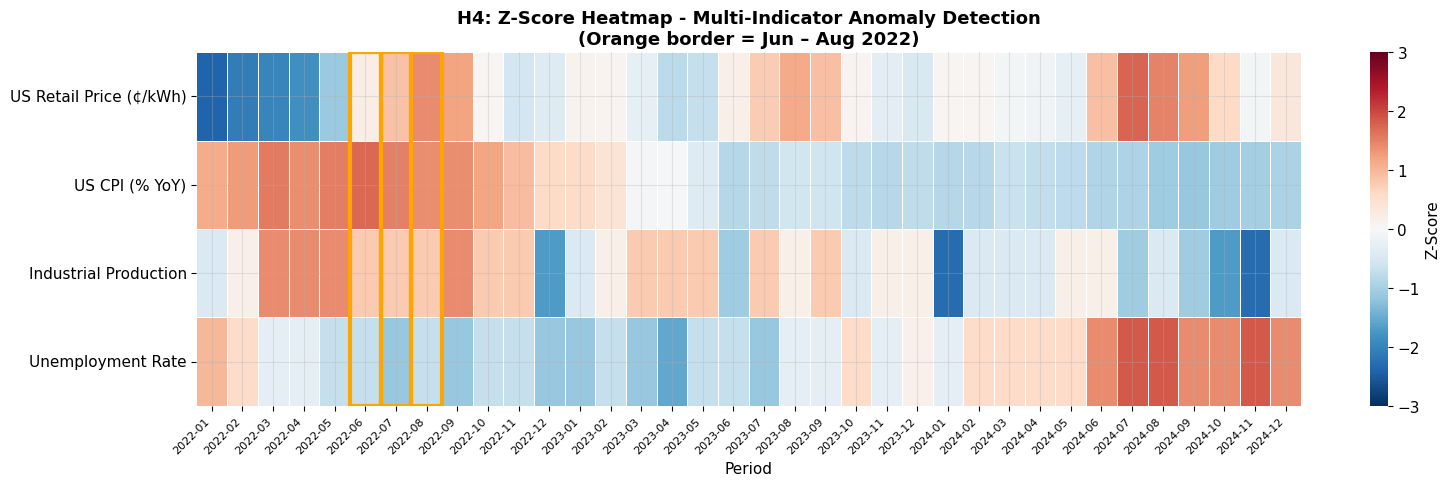

H4 - Anomaly Detection Results

Z-Score pada periode Jun – Aug 2022:


,period,z_price_cents_kwh,z_cpi_pct_yoy,z_industrial_prod_usd,z_unemployment_rate,n_anomaly_indicators,max_abs_zscore
5,2022-06,0.227,1.729,0.794,-0.711,0,1.729
6,2022-07,0.870,1.502,0.794,-1.137,0,1.502
7,2022-08,1.426,1.397,0.794,-0.711,0,1.426



Conclusion for H4:
   Rata-rata max |Z-score| Jun – Aug 2022 : 1.5525
   Semua bulan memiliki ≥2 anomaly indicators: False
   -> H4 SEBAGIAN DIDUKUNG: Anomali terdeteksi tapi tidak semua indikator > 2.0


In [45]:
# Heatmap Z Score
fig, ax = plt.subplots(figsize=(16, 5))

# Buat matrix untuk heatmap
heatmap_data = df_zscore.set_index('period')[z_cols].T
heatmap_data.index = [INDICATORS[c.replace('z_', '')] for c in z_cols]

sns.heatmap(heatmap_data, cmap='RdBu_r', center=0, vmin=-3, vmax=3,
            annot=False, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Z-Score'})

# Highlight kolom Jun-Aug 2022
target_cols = [p for p in df_zscore['period'].tolist()
               if '2022-06' <= p <= '2022-08']
all_periods  = df_zscore['period'].tolist()
for tc in target_cols:
    if tc in all_periods:
        idx = all_periods.index(tc)
        ax.add_patch(plt.Rectangle((idx, 0), 1, len(z_cols),
                     fill=False, edgecolor='orange', lw=3))

ax.set_title('H4: Z-Score Heatmap - Multi-Indicator Anomaly Detection\n(Orange border = Jun – Aug 2022)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Period', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('../Reports/H4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Kesimpulan H4
target_anomaly = df_zscore[
    (df_zscore['period'] >= '2022-06') &
    (df_zscore['period'] <= '2022-08')
]

print("H4 - Anomaly Detection Results")
print("\nZ-Score pada periode Jun – Aug 2022:")
display(target_anomaly[['period'] + z_cols + ['n_anomaly_indicators', 'max_abs_zscore']].round(3))

all_anomalous = target_anomaly['n_anomaly_indicators'].min() >= 2
avg_max_z     = target_anomaly['max_abs_zscore'].mean()

print(f"\nConclusion for H4:")
print(f"   Rata-rata max |Z-score| Jun – Aug 2022 : {avg_max_z:.4f}")
print(f"   Semua bulan memiliki ≥2 anomaly indicators: {all_anomalous}")
if avg_max_z > 2.0 and all_anomalous:
    print("   -> H4 DIDUKUNG: Jun –A ug 2022 adalah periode anomali SIMULTAN")
    print("     di semua indikator utama (Z-score > 2.0)")
elif avg_max_z > 1.5:
    print("   -> H4 SEBAGIAN DIDUKUNG: Anomali terdeteksi tapi tidak semua indikator > 2.0")
else:
    print("   -> H4 TIDAK DIDUKUNG")

---
# Final Conclusion

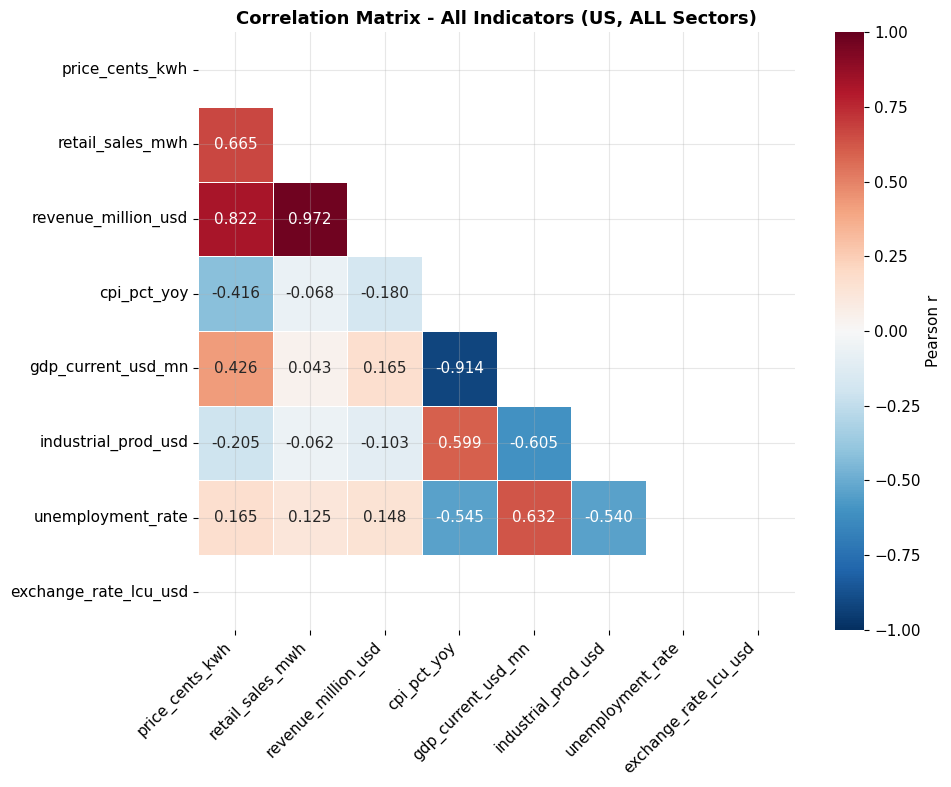

In [46]:
# Correlation Matrix Semua Indikator
df_corr_matrix = fact_ee[
    (fact_ee['sector_id'] == 'ALL') &
    (fact_ee['country_code'] == 'US')
][[c for c in cols_exist if c in fact_ee.columns]].dropna()

corr_matrix = df_corr_matrix.corr(method='pearson')

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Pearson r'})
ax.set_title('Correlation Matrix - All Indicators (US, ALL Sectors)',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../Reports/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()